# Лабораторная работа
## Тема: Алгоритмы сокращения размерности - метод главных компонент (PCA)

### 1. Название и краткая информация о сдаваемом методе

Метод главных компонент (`Principal Component Analysis`, `PCA`) используется для сокращения размерности числовых данных. Алгоритм заменяет исходные признаки новыми признаками - главными компонентами. Каждая главная компонента является линейной комбинацией исходных признаков, а компоненты упорядочены по доле объясненной дисперсии: первая сохраняет максимальную часть разброса данных, вторая - максимальную часть оставшегося разброса, и так далее.

В лабораторной работе PCA применяется к датасету **Human Activity Recognition Using Smartphones**. Набор содержит 10 299 наблюдений, 561 числовой признак и 6 классов активности человека. Датасет хорошо подходит для PCA: признаков много, все признаки числовые, классы распределены сравнительно равномерно, а модель после сокращения размерности сохраняет высокое качество.
        


### 2. Блок с используемыми библиотеками

В работе используются `pandas` и `numpy` для обработки данных, `matplotlib` и `seaborn` для визуализации, а также инструменты `scikit-learn` для стандартизации признаков, построения PCA, обучения классификатора и оценки качества модели.
        


In [20]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

sns.set_theme(style="whitegrid", font_scale=1.0)
RANDOM_STATE = 42
        


### 3. Блок с описанием и демонстрацией используемого датасета

В работе используется датасет **Human Activity Recognition Using Smartphones**. Это набор данных для распознавания физической активности человека по показаниям датчиков движения. Эксперимент проводился так: участники выполняли несколько обычных действий, а смартфон, закрепленный на поясе, записывал сигналы акселерометра и гироскопа. Акселерометр измеряет ускорение, гироскоп измеряет угловую скорость, то есть повороты и вращения устройства.

Один объект в датасете - это не один человек и не один телефон, а короткий временной фрагмент движения. Для каждого такого фрагмента из сырых сигналов были рассчитаны числовые признаки: средние значения, стандартные отклонения, максимумы, минимумы, энергия сигнала, частотные характеристики и углы между векторами движения.

Целевая переменная `ActivityName` показывает, какое действие выполнял человек в этот момент. В датасете 6 классов:

- `WALKING`;
- `WALKING_UPSTAIRS`;
- `WALKING_DOWNSTAIRS`;
- `SITTING`;
- `STANDING`;
- `LAYING`.

Примеры признаков:

- `tBodyAccmeanX` - среднее ускорение тела по оси X во временной области;
- `tBodyAccstdY` - стандартное отклонение ускорения тела по оси Y;
- `tGravityAccmeanZ` - средняя компонента ускорения, связанная с гравитацией, по оси Z;
- `tBodyGyrostdX` - разброс показаний гироскопа по оси X;
- `fBodyAccmeanFreqX` - средневзвешенная частота сигнала ускорения по оси X;
- `angle(tBodyAccMean,gravity)` - угол между средним ускорением тела и направлением гравитации.

Из набора признаков исключаются только служебные столбцы `subject`, `Activity` и `ActivityName`. Для обучения остаются 561 числовой признак. Такой датасет хорошо подходит для PCA, потому что признаков много, они частично связаны друг с другом, а классы активности распределены достаточно ровно.
        


In [21]:
candidate_paths = [
    Path("uci_har_combined.csv"),
    Path("block-4/pca/uci_har_combined.csv"),
    Path("../block-4/pca/uci_har_combined.csv"),
    Path("../../block-4/pca/uci_har_combined.csv"),
    Path(r"C:\Users\avdee\PycharmProjects\mmo-2026\block-4\pca\uci_har_combined.csv"),
    Path(r"C:\Users\avdee\OneDrive\Документы\New project\har_csv\uci_har_combined.csv"),
]

data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("Файл uci_har_combined.csv не найден рядом с ноутбуком или в папках проекта.")

df = pd.read_csv(data_path)

target_column = "ActivityName"
service_columns = ["subject", "Activity", target_column]
feature_columns = [column for column in df.columns if column not in service_columns]

X = df[feature_columns]
y = df[target_column]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = label_encoder.classes_

print(f"Используемый файл: {data_path}")
print(f"Размер датасета: {df.shape[0]} объектов, {len(feature_columns)} признаков")
print(f"Количество классов: {y.nunique()}")
display(df.head())

feature_examples = pd.DataFrame(
    {
        "feature": [
            "1 tBodyAccmeanX",
            "4 tBodyAccstdX",
            "42 tGravityAccmeanY",
            "124 tBodyGyrostdX",
            "294 fBodyAccmeanFreqX",
            "555 angletBodyAccMeangravity",
        ],
        "meaning": [
            "среднее ускорение тела по оси X",
            "стандартное отклонение ускорения тела по оси X",
            "средняя компонента гравитационного ускорения по оси Y",
            "стандартное отклонение угловой скорости гироскопа по оси X",
            "средневзвешенная частота сигнала ускорения по оси X",
            "угол между средним ускорением тела и направлением гравитации",
        ],
    }
)

display(feature_examples)
        


Используемый файл: uci_har_combined.csv
Размер датасета: 10299 объектов, 561 признаков
Количество классов: 6


,1 tBodyAccmeanX,2 tBodyAccmeanY,3 tBodyAccmeanZ,4 tBodyAccstdX,5 tBodyAccstdY,6 tBodyAccstdZ,7 tBodyAccmadX,8 tBodyAccmadY,9 tBodyAccmadZ,10 tBodyAccmaxX,...,555 angletBodyAccMeangravity,556 angletBodyAccJerkMeangravityMean,557 angletBodyGyroMeangravityMean,558 angletBodyGyroJerkMeangravityMean,559 angleXgravityMean,560 angleYgravityMean,561 angleZgravityMean,subject,Activity,ActivityName
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,5,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,5,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,5,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,5,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,5,STANDING


,feature,meaning
0,1 tBodyAccmeanX,среднее ускорение тела по оси X
1,4 tBodyAccstdX,стандартное отклонение ускорения тела по оси X
2,42 tGravityAccmeanY,средняя компонента гравитационного ускорения п...
3,124 tBodyGyrostdX,стандартное отклонение угловой скорости гироск...
4,294 fBodyAccmeanFreqX,средневзвешенная частота сигнала ускорения по ...
5,555 angletBodyAccMeangravity,угол между средним ускорением тела и направлен...


,count
ActivityName,
LAYING,1944
SITTING,1777
STANDING,1906
WALKING,1722
WALKING_DOWNSTAIRS,1406
WALKING_UPSTAIRS,1544


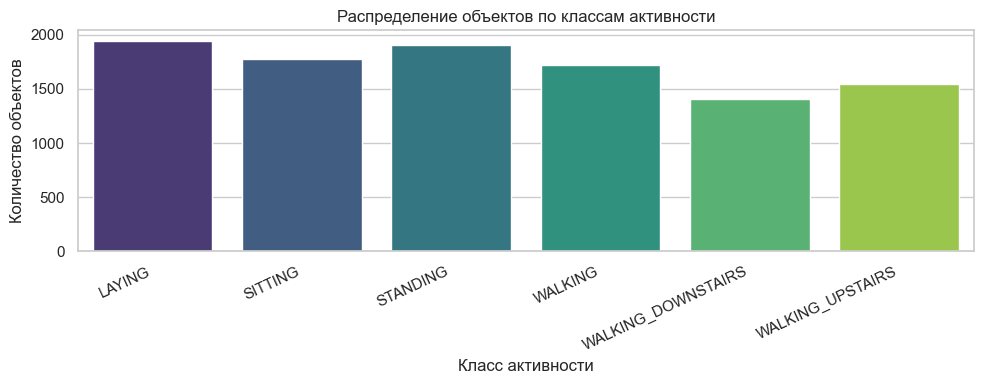

In [22]:
class_distribution = y.value_counts().sort_index()

display(class_distribution.to_frame("count"))

plt.figure(figsize=(10, 4))
sns.barplot(x=class_distribution.index, y=class_distribution.values, palette="viridis")
plt.title("Распределение объектов по классам активности")
plt.xlabel("Класс активности")
plt.ylabel("Количество объектов")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()
        


,mean,std,min,max
1 tBodyAccmeanX,0.274,0.068,-1.0,1.0
2 tBodyAccmeanY,-0.018,0.037,-1.0,1.0
3 tBodyAccmeanZ,-0.109,0.053,-1.0,1.0
4 tBodyAccstdX,-0.608,0.439,-1.0,1.0
5 tBodyAccstdY,-0.510,0.500,-1.0,1.0
6 tBodyAccstdZ,-0.613,0.404,-1.0,1.0
7 tBodyAccmadX,-0.634,0.413,-1.0,1.0
8 tBodyAccmadY,-0.526,0.484,-1.0,1.0
9 tBodyAccmadZ,-0.615,0.399,-1.0,1.0
10 tBodyAccmaxX,-0.467,0.539,-1.0,1.0


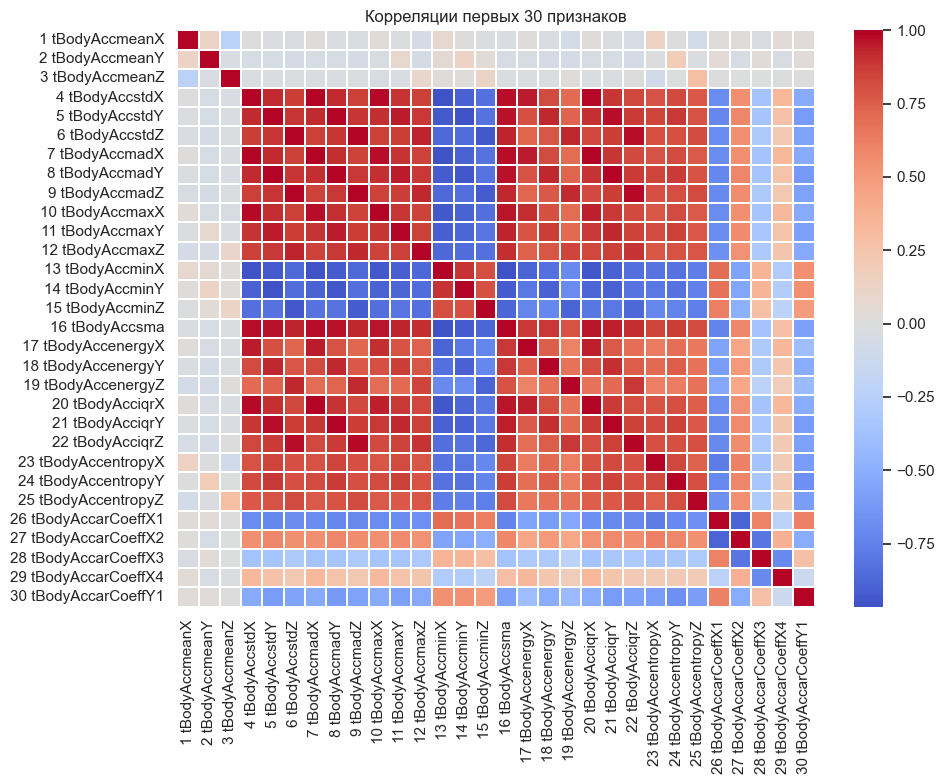

In [23]:
display(X.iloc[:, :12].describe().T[["mean", "std", "min", "max"]].round(3))

sample_corr = X.iloc[:, :30].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(sample_corr, cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Корреляции первых 30 признаков")
plt.tight_layout()
plt.show()
        


### 4. Подготовка данных

Для PCA нужна стандартизация признаков. Если признаки имеют разные масштабы, главные компоненты будут слишком сильно зависеть от признаков с большими численными значениями. Поэтому перед PCA используется `StandardScaler`.

Данные делятся на обучающую и тестовую выборки со стратификацией, чтобы в обеих частях сохранились пропорции всех 6 классов активности.
        


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_encoded,
)

y_train_names = pd.Series(label_encoder.inverse_transform(y_train), name=target_column)
y_test_names = pd.Series(label_encoder.inverse_transform(y_test), name=target_column)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")
display(y_train_names.value_counts(normalize=True).sort_index().rename("train_share").to_frame().round(3))
display(y_test_names.value_counts(normalize=True).sort_index().rename("test_share").to_frame().round(3))
        


Обучающая выборка: (7724, 561)
Тестовая выборка: (2575, 561)


,train_share
ActivityName,
LAYING,0.189
SITTING,0.173
STANDING,0.185
WALKING,0.167
WALKING_DOWNSTAIRS,0.137
WALKING_UPSTAIRS,0.150


,test_share
ActivityName,
LAYING,0.189
SITTING,0.172
STANDING,0.185
WALKING,0.167
WALKING_DOWNSTAIRS,0.136
WALKING_UPSTAIRS,0.150


### 5. Анализ объясненной дисперсии PCA

Сначала обучим PCA на стандартизированных признаках и посмотрим, сколько информации сохраняют главные компоненты. В исходном датасете 561 признак, поэтому задача сокращения размерности здесь действительно существенная.
        


In [25]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA(random_state=RANDOM_STATE)
X_pca_full = pca_full.fit_transform(X_scaled)

variance_table = pd.DataFrame(
    {
        "component": np.arange(1, X.shape[1] + 1),
        "explained_variance_ratio": pca_full.explained_variance_ratio_,
        "cumulative_variance": np.cumsum(pca_full.explained_variance_ratio_),
    }
)

n_components_90 = int(np.argmax(variance_table["cumulative_variance"].values >= 0.90) + 1)
n_components_95 = int(np.argmax(variance_table["cumulative_variance"].values >= 0.95) + 1)

print(f"Компонент для сохранения не менее 90% дисперсии: {n_components_90}")
print(f"Компонент для сохранения не менее 95% дисперсии: {n_components_95}")
display(variance_table.head(15).round(4))
        


Компонент для сохранения не менее 90% дисперсии: 65
Компонент для сохранения не менее 95% дисперсии: 104


,component,explained_variance_ratio,cumulative_variance
0,1,0.5074,0.5074
1,2,0.0624,0.5698
2,3,0.0269,0.5967
3,4,0.0245,0.6212
4,5,0.0189,0.6401
5,6,0.0163,0.6564
6,7,0.0141,0.6706
7,8,0.0122,0.6827
8,9,0.0099,0.6926
9,10,0.0095,0.7021


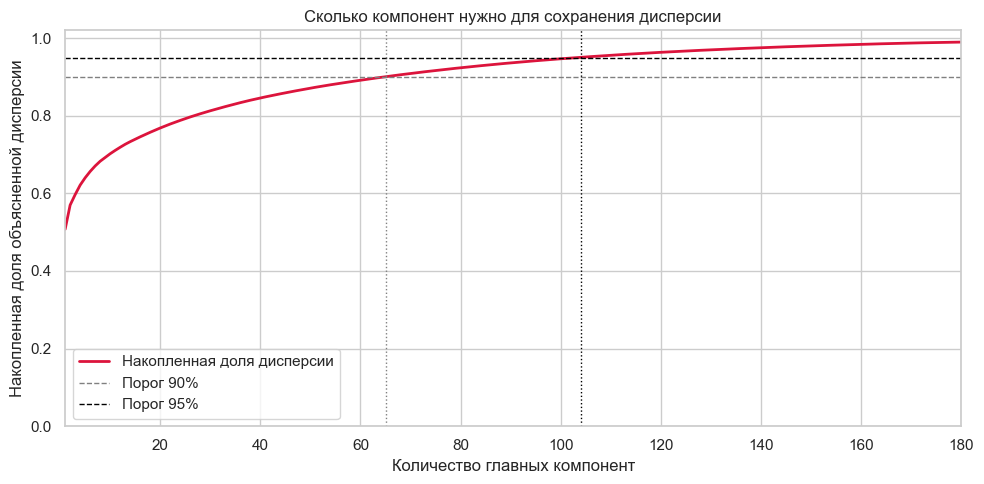

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(
    variance_table["component"],
    variance_table["cumulative_variance"],
    color="crimson",
    linewidth=2,
    label="Накопленная доля дисперсии",
)
plt.axhline(0.90, color="gray", linestyle="--", linewidth=1, label="Порог 90%")
plt.axhline(0.95, color="black", linestyle="--", linewidth=1, label="Порог 95%")
plt.axvline(n_components_90, color="gray", linestyle=":", linewidth=1)
plt.axvline(n_components_95, color="black", linestyle=":", linewidth=1)
plt.xlim(1, 180)
plt.ylim(0, 1.02)
plt.xlabel("Количество главных компонент")
plt.ylabel("Накопленная доля объясненной дисперсии")
plt.title("Сколько компонент нужно для сохранения дисперсии")
plt.legend()
plt.tight_layout()
plt.show()
        


### 6. Визуализация данных в пространстве двух главных компонент

Две главные компоненты используются как визуальная проекция. Они не обязаны давать максимальное качество классификации, но помогают увидеть общую структуру данных после перехода из 561-мерного пространства в двумерное.
        


Две главные компоненты сохраняют 56.98% общей дисперсии


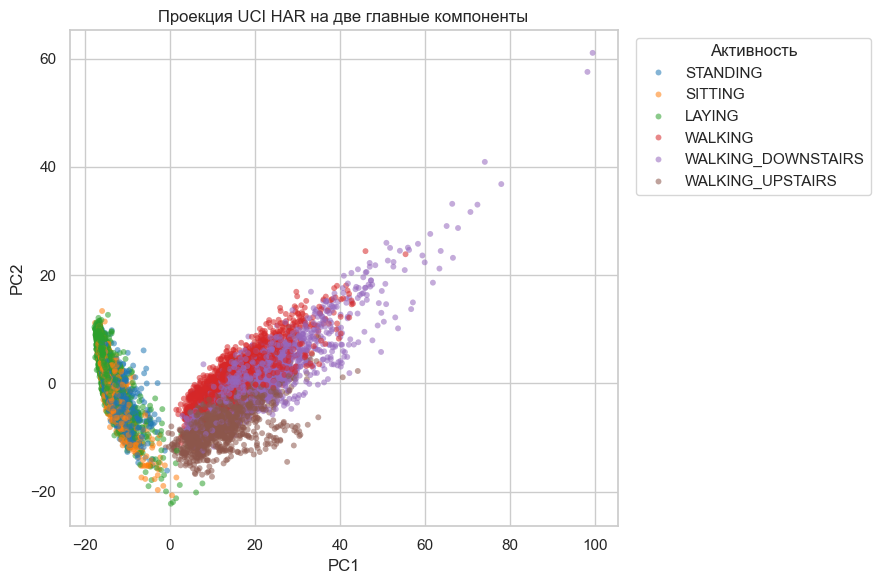

In [27]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_2d_df = pd.DataFrame(X_pca_2d, columns=["PC1", "PC2"])
pca_2d_df[target_column] = y.values

print(
    "Две главные компоненты сохраняют "
    f"{pca_2d.explained_variance_ratio_.sum():.2%} общей дисперсии"
)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=pca_2d_df,
    x="PC1",
    y="PC2",
    hue=target_column,
    palette="tab10",
    s=18,
    alpha=0.55,
    edgecolor="none",
)
plt.title("Проекция UCI HAR на две главные компоненты")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Активность", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
        


In [28]:
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=X.columns,
    columns=["PC1", "PC2"],
)

top_pc1 = loadings["PC1"].abs().sort_values(ascending=False).head(8).index
top_pc2 = loadings["PC2"].abs().sort_values(ascending=False).head(8).index

print("Признаки с наибольшим вкладом в PC1:")
display(loadings.loc[top_pc1, ["PC1"]].sort_values("PC1", key=np.abs, ascending=False).round(3))

print("Признаки с наибольшим вкладом в PC2:")
display(loadings.loc[top_pc2, ["PC2"]].sort_values("PC2", key=np.abs, ascending=False).round(3))
        


Признаки с наибольшим вкладом в PC1:


,PC1
281 fBodyAccsma,0.059
360 fBodyAccJerksma,0.059
439 fBodyGyrosma,0.059
96 tBodyAccJerksma,0.059
227 tBodyAccJerkMagmean,0.058
232 tBodyAccJerkMagsma,0.058
516 fBodyBodyAccJerkMagmean,0.058
521 fBodyBodyAccJerkMagsma,0.058


Признаки с наибольшим вкладом в PC2:


,PC2
296 fBodyAccmeanFreqZ,0.124
249 tBodyGyroMagarCoeff1,0.121
513 fBodyAccMagmeanFreq,0.120
74 tGravityAccarCoeffZ1,0.120
210 tBodyAccMagarCoeff1,0.119
223 tGravityAccMagarCoeff1,0.119
75 tGravityAccarCoeffZ2,-0.119
76 tGravityAccarCoeffZ3,0.118


### 7. Обучение нейронной сети без PCA и с PCA

Для проверки качества используется нейронная сеть прямого распространения (`MLPClassifier`). Это многослойный перцептрон: входной слой получает признаки, один скрытый слой с функцией активации `ReLU` выделяет нелинейные зависимости, а выходной слой относит объект к одному из 6 классов активности.

Сравниваются четыре варианта:

- модель на всех 561 стандартизированном признаке;
- модель после PCA с сохранением 95% дисперсии;
- модель после PCA с 50 компонентами;
- модель после PCA до двух компонент.

Такой эксперимент показывает компромисс между размерностью признакового пространства и качеством классификации.
        


In [29]:
def make_model(pca=None):
    steps = [("scaler", StandardScaler())]
    if pca is not None:
        steps.append(("pca", pca))
    steps.append(
        (
            "model",
            MLPClassifier(
                hidden_layer_sizes=(64,),
                activation="relu",
                solver="adam",
                batch_size=128,
                learning_rate_init=0.001,
                max_iter=80,
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=8,
                random_state=RANDOM_STATE,
            ),
        )
    )
    return Pipeline(steps)


def evaluate_pipeline(name, pipeline):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    return {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
        "pipeline": pipeline,
        "predictions": y_pred,
    }


models = [
    ("Все признаки", make_model()),
    ("PCA 95% дисперсии", make_model(PCA(n_components=0.95, random_state=RANDOM_STATE))),
    ("PCA 50 компонент", make_model(PCA(n_components=50, random_state=RANDOM_STATE))),
    ("PCA 2 компоненты", make_model(PCA(n_components=2, random_state=RANDOM_STATE))),
]

results = [evaluate_pipeline(name, pipeline) for name, pipeline in models]

metrics_table = pd.DataFrame(
    [{k: v for k, v in result.items() if k not in {"pipeline", "predictions"}} for result in results]
)

display(metrics_table.round(4))
        


,model,accuracy,macro_f1
0,Все признаки,0.9775,0.9784
1,PCA 95% дисперсии,0.9662,0.9671
2,PCA 50 компонент,0.9452,0.9471
3,PCA 2 компоненты,0.5495,0.5176


Количество компонент в PCA-модели с порогом 95%: 104
Количество эпох обучения нейронной сети: 38
Отчет классификации для модели с PCA 95% дисперсии:
                    precision    recall  f1-score   support

            LAYING       1.00      0.99      1.00       486
           SITTING       0.92      0.93      0.92       444
          STANDING       0.93      0.93      0.93       477
           WALKING       1.00      0.99      0.99       431
WALKING_DOWNSTAIRS       0.97      0.99      0.98       351
  WALKING_UPSTAIRS       0.98      0.98      0.98       386

          accuracy                           0.97      2575
         macro avg       0.97      0.97      0.97      2575
      weighted avg       0.97      0.97      0.97      2575



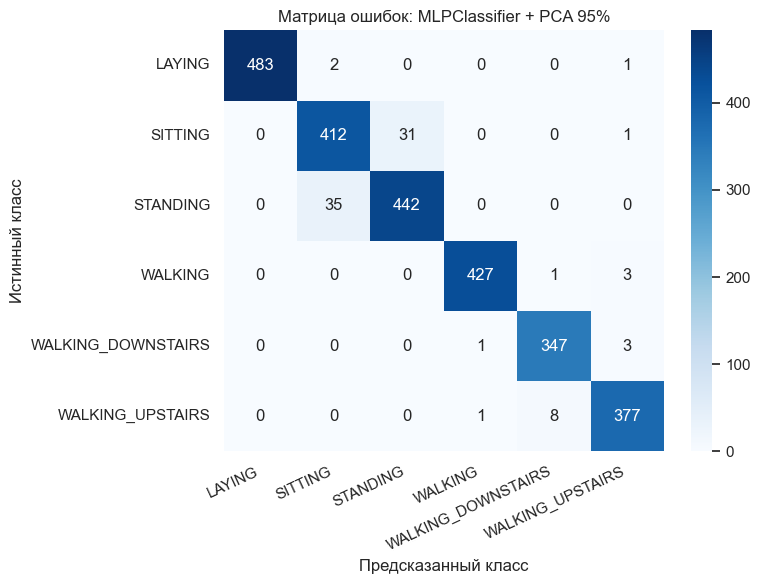

In [30]:
pca_95_result = next(result for result in results if result["model"] == "PCA 95% дисперсии")
pca_95_pipeline = pca_95_result["pipeline"]
pca_95_predictions = pca_95_result["predictions"]

print(
    "Количество компонент в PCA-модели с порогом 95%: "
    f"{pca_95_pipeline.named_steps['pca'].n_components_}"
)
print(
    "Количество эпох обучения нейронной сети: "
    f"{pca_95_pipeline.named_steps['model'].n_iter_}"
)

print("Отчет классификации для модели с PCA 95% дисперсии:")
print(classification_report(y_test, pca_95_predictions, target_names=class_names))

label_ids = np.arange(len(class_names))
cm = confusion_matrix(y_test, pca_95_predictions, labels=label_ids)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title("Матрица ошибок: MLPClassifier + PCA 95%")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.xticks(rotation=25, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
        


### 8. Влияние количества компонент на качество модели

Дополнительно проверим, как меняется качество модели при разном количестве главных компонент. Для этого обучим одну и ту же модель на тестовом разбиении с несколькими вариантами размерности.
        


In [31]:
component_grid = [2, 5, 10, 20, 30, 50, 75, 100, n_components_95, 150]
component_grid = sorted(set(n for n in component_grid if n <= X.shape[1]))

component_scores = []

for n_components in component_grid:
    pipeline = make_model(PCA(n_components=n_components, random_state=RANDOM_STATE))
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    component_scores.append(
        {
            "n_components": n_components,
            "test_accuracy": accuracy_score(y_test, y_pred),
            "test_macro_f1": f1_score(y_test, y_pred, average="macro"),
            "cumulative_variance": variance_table.loc[
                variance_table["component"] == n_components,
                "cumulative_variance",
            ].iat[0],
        }
    )

component_scores = pd.DataFrame(component_scores)
display(component_scores.round(4))
        


,n_components,test_accuracy,test_macro_f1,cumulative_variance
0,2,0.5495,0.5176,0.5698
1,5,0.8221,0.8173,0.6401
2,10,0.8718,0.8733,0.7021
3,20,0.9060,0.9072,0.7684
4,30,0.9208,0.9218,0.8128
5,50,0.9452,0.9471,0.8710
6,75,0.9631,0.9643,0.9165
7,100,0.9701,0.9713,0.9467
8,104,0.9662,0.9671,0.9505
9,150,0.9685,0.9694,0.9799


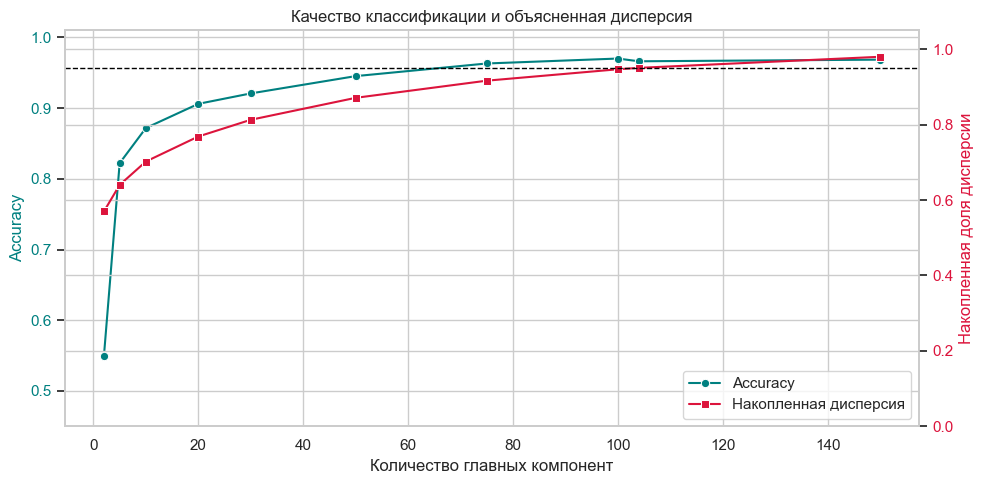

In [32]:
fig, ax1 = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=component_scores,
    x="n_components",
    y="test_accuracy",
    marker="o",
    color="teal",
    ax=ax1,
    label="Accuracy",
)
ax1.set_xlabel("Количество главных компонент")
ax1.set_ylabel("Accuracy", color="teal")
ax1.tick_params(axis="y", labelcolor="teal")
ax1.set_ylim(0.45, 1.01)

ax2 = ax1.twinx()
sns.lineplot(
    data=component_scores,
    x="n_components",
    y="cumulative_variance",
    marker="s",
    color="crimson",
    ax=ax2,
    label="Накопленная дисперсия",
)
ax2.axhline(0.95, color="black", linestyle="--", linewidth=1)
ax2.set_ylabel("Накопленная доля дисперсии", color="crimson")
ax2.tick_params(axis="y", labelcolor="crimson")
ax2.set_ylim(0, 1.05)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="lower right")
ax2.get_legend().remove()

plt.title("Качество классификации и объясненная дисперсия")
plt.tight_layout()
plt.show()
        


### 9. Итоговые выводы

В работе был рассмотрен метод главных компонент `PCA` как алгоритм сокращения размерности. На датасете `Human Activity Recognition Using Smartphones` исходные 561 числовой признак были преобразованы в пространство главных компонент.

Результаты показывают, что PCA позволяет сильно уменьшить размерность без критической потери качества. Модель на всех признаках показывает максимальную точность, но модель с PCA, сохраняющая 95% дисперсии, использует примерно в пять раз меньше признаков и сохраняет высокое качество классификации. Двумерная PCA-проекция удобна для визуального анализа структуры данных, однако для полноценной классификации двух компонент недостаточно.

Таким образом, PCA полезен как для визуализации многомерных данных, так и для предварительной обработки перед обучением моделей, особенно когда исходных числовых признаков очень много.
        


In [33]:
pca_95 = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_pca_95 = pca_95.fit_transform(StandardScaler().fit_transform(X_train))

print(X_train.shape)
print(X_train_pca_95.shape)


(7724, 561)
(7724, 104)
